# The action square of the policy

The action of the policy is $\mathbf{a} \in [-1, 1]^2$ and becomes the slope of the plate as $\mathbf{u} = U_{MAX}\ \mathbf{a}$. `U_MAX` is chosen here as the half width of the largest square centred on the origin whose slopes keep the three motors within $Q_{RANGE}$ of the home angle: with it every action, corners included, is a pose the servos hold without being clipped.

The sweep below colours each slope by the largest travel of a motor, $\max_i |q_i - Q_{HOME}|$, green where it is within the travel and red beyond it, blank where the pose is not reachable at all. The green region is convex, so the square is inside it as soon as its four corners are.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

# the kernel may start in the repository root or in this folder, depending on how Jupyter was launched
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts" / "kinematics.py").exists())
sys.path.insert(0, str(ROOT / "scripts"))

import kinematics

In [2]:
# SWEEP
U_LIM = 1.0
U_STEP = 0.01

# ACTUATION, as in scripts/hardware.py
Q_HOME = 60.0
Q_RANGE = 15.0                           # travel allowed around the home angle


def travel(u):
    # largest travel of a motor from home, NaN where the pose is not reachable
    q = kinematics.solve(u, kinematics.H_NOM)
    return np.nan if q is None else np.max(np.abs(q - Q_HOME))

In [3]:
# the travel over the whole action square
u = np.arange(-U_LIM, U_LIM + U_STEP, U_STEP)
ux, uy = np.meshgrid(u, u)
travel_map = np.array([[travel(p) for p in zip(row_x, row_y)] for row_x, row_y in zip(ux, uy)])

u_max = 0.0
for half_width in np.arange(U_STEP, U_LIM, U_STEP):
    corners = [(sx * half_width, sy * half_width) for sx in (-1, 1) for sy in (-1, 1)]
    if not all(travel(c) <= Q_RANGE for c in corners):
        break
    u_max = half_width

print(f"U_MAX = {u_max}")

U_MAX = 0.14


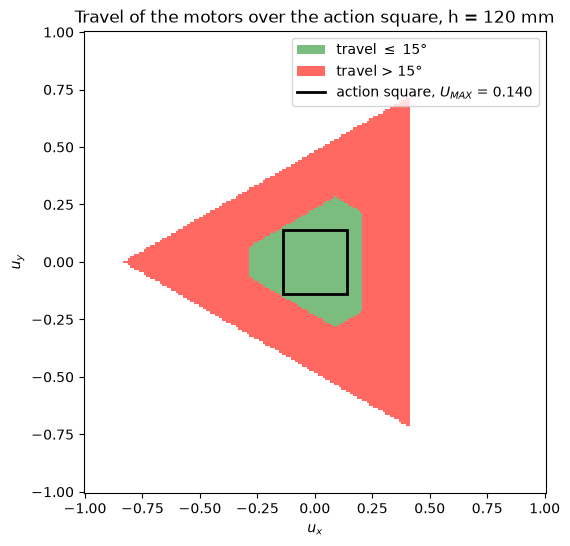

In [4]:
GREEN, RED = "#7ABD7E", "#FF6961"
cmap = ListedColormap([GREEN, RED])
norm = BoundaryNorm([0, Q_RANGE, np.inf], cmap.N)

square = plt.Rectangle((-u_max, -u_max), 2 * u_max, 2 * u_max, fill=False, edgecolor="black", linewidth=2)
legend = [Patch(facecolor=GREEN, label=f"travel $\\leq$ {Q_RANGE:.0f}°"),
          Patch(facecolor=RED, label=f"travel > {Q_RANGE:.0f}°"),
          plt.Line2D([], [], color="black", linewidth=2, label=f"action square, $U_{{MAX}}$ = {u_max:.3f}")]

fig, ax = plt.subplots(figsize=(7, 6))
ax.pcolormesh(ux, uy, travel_map, cmap=cmap, norm=norm, shading="nearest")
ax.add_patch(square)
ax.legend(handles=legend, loc="upper right")
ax.set_xlabel("$u_x$")
ax.set_ylabel("$u_y$")
ax.set_title(f"Travel of the motors over the action square, h = {kinematics.H_NOM:.0f} mm")
ax.set_aspect("equal")
plt.show()